##### Retail Sales Analysis with Some Missing Data
##### Business Context
You are a data analyst at "QuickMart," a small retail store that sells products across several categories including Electronics, Clothing, Home Goods, Books, and Groceries. The store manager has been recording all sales transactions, but the dataset contains some missing values due to occasional data entry issues. The manager still needs insights to make better inventory and staffing decisions.
Business Problem
The store manager needs to understand sales patterns from the last month to make better decisions about inventory and staffing. They want to know which products and categories sell best, when sales are highest, and how revenue is distributed across product lines.
Your Task
Using pandas, analyze the sales data provided in retail_sales_data.csv to:

###### 1.	Explore the data and handle missing values:
○	Load the dataset and check its basic structure
○	Identify where missing values exist in the dataset
○	Use simple techniques to handle missing values (such as filling in missing totals where price and quantity are available)
○	Note: You don't need complex imputation - focus on straightforward approaches

###### 2.	Analyze category performance:
○	Which product categories generate the most sales?
○	Which categories bring in the most revenue?
○	Create a simple bar chart showing revenue by category

###### 3.	Find popular products:
○	What are the top 5 products by quantity sold?
○	What are the top 5 products by total revenue?
○	Do you notice any products that sell in high quantities but don't generate as much revenue (or vice versa)?

###### 4.	Look at when people shop:
○	Which days of the week have the highest sales?
○	Create a simple line or bar chart showing sales by day of the week

###### 5.	Provide basic statistics:
○	What is the average transaction value?
○	What quantity do customers typically purchase?
○	What is the price range of products in each category?

##### Data Dictionary
The retail_sales_data.csv file contains the following columns:
●	transaction_id: Unique identifier for each transaction
●	date: Date of the transaction (YYYY-MM-DD format) - some values missing
●	category: Product category (Electronics, Clothing, Home Goods, Books, Groceries) - some values missing
●	product: Specific product name - some values missing
●	price: Unit price of the product - some values missing
●	quantity: Number of units purchased in the transaction - some values missing
●	total: Total amount for the transaction (price × quantity) - some values missing

##### Data Quality Notes
●	There are some missing values in the dataset
●	For analysis, you can either drop rows with missing values or use simple methods to fill them in

##### Deliverables
1.	A cleaned version of the dataset
2.	Summary of sales by category with a visualization
3.	List of top 5 products by quantity and by revenue
4.	Analysis of which days have highest sales with a visualization
5.	Basic summary statistics for the data
6.	3-5 key insights for the store manager about what the data tells us
  
##### Evaluation Criteria
Your analysis will be evaluated based on:
1.	Basic data cleaning to handle missing values
2.	Clear explanations of your findings
3.	Simple but effective visualizations
4.	Practical insights for the store manager


In [3]:
import pandas as pd
import numpy as np

##### 1) Exploring data and handling missing values>>>

##### Basic Structure

In [147]:
df=pd.read_csv("retail_sales_data.csv")

In [148]:
df

,transaction_id,date,category,product,price,quantity,total
0,10001,2025-08-01,Clothing,Socks,41.86,3.0,125.58
1,10002,2025-08-01,Groceries,Eggs,NaN,1.0,11.52
2,10003,2025-08-01,Electronics,Webcam,67.75,NaN,135.50
3,10004,2025-08-01,Groceries,Milk,4.03,3.0,NaN
4,10005,2025-08-01,Clothing,NaN,28.37,1.0,28.37
...,...,...,...,...,...,...,...
95,10096,2025-08-05,Books,Children's Book,15.34,2.0,30.68
96,10097,2025-08-05,Clothing,Hat,30.11,2.0,60.22
97,10098,NaN,Books,Self-Help,10.66,4.0,42.64
98,10099,2025-08-05,Groceries,Coffee,13.81,3.0,41.43


In [6]:
df.shape

(100, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  100 non-null    int64  
 1   date            94 non-null     object 
 2   category        95 non-null     object 
 3   product         97 non-null     object 
 4   price           94 non-null     float64
 5   quantity        91 non-null     float64
 6   total           93 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 5.6+ KB


In [8]:
df.columns

Index(['transaction_id', 'date', 'category', 'product', 'price', 'quantity',
       'total'],
      dtype='object')

In [9]:
df.dtypes

transaction_id      int64
date               object
category           object
product            object
price             float64
quantity          float64
total             float64
dtype: object

In [10]:
df.describe()

,transaction_id,price,quantity,total
count,100.000000,94.000000,91.000000,93.000000
mean,10050.500000,27.669255,2.516484,66.095699
std,29.011492,22.039129,1.158185,59.567726
min,10001.000000,2.330000,1.000000,2.330000
25%,10025.750000,13.005000,1.000000,24.550000
50%,10050.500000,21.680000,3.000000,49.470000
75%,10075.250000,34.655000,4.000000,88.760000
max,10100.000000,96.890000,4.000000,358.880000


##### Identifying missing values>>>

In [11]:
df.isnull()

,transaction_id,date,category,product,price,quantity,total
0,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False
2,False,False,False,False,False,True,False
3,False,False,False,False,False,False,True
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False
97,False,True,False,False,False,False,False
98,False,False,False,False,False,False,False


In [149]:
df.isnull().sum()

transaction_id    0
date              6
category          5
product           3
price             6
quantity          9
total             7
dtype: int64

In [13]:
df[df.isnull().any(axis=1)]

,transaction_id,date,category,product,price,quantity,total
1,10002,2025-08-01,Groceries,Eggs,NaN,1.0,11.52
2,10003,2025-08-01,Electronics,Webcam,67.75,NaN,135.50
3,10004,2025-08-01,Groceries,Milk,4.03,3.0,NaN
4,10005,2025-08-01,Clothing,NaN,28.37,1.0,28.37
6,10007,2025-08-01,NaN,Plate Set,27.78,1.0,27.78
8,10009,2025-08-01,Home Goods,Pillow,37.85,NaN,NaN
13,10014,NaN,Groceries,Coffee,9.95,2.0,19.90
17,10018,2025-08-02,Electronics,Power Bank,NaN,4.0,244.56
19,10020,2025-08-02,Home Goods,Candle,26.26,NaN,26.26
21,10022,2025-08-02,Electronics,USB Cable,95.91,4.0,NaN


##### Handling missing values>>

In [150]:
# where total is missing but price and quantity are present
df["total"]=df["total"].fillna(df['price']*df['quantity'])

In [15]:
df['total']

0     125.58
1      11.52
2     135.50
3      12.09
4      28.37
       ...  
95     30.68
96     60.22
97     42.64
98     41.43
99     62.48
Name: total, Length: 100, dtype: float64

In [16]:
df['total'].isnull()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Name: total, Length: 100, dtype: bool

In [17]:
df[df['total'].isnull()]

,transaction_id,date,category,product,price,quantity,total
8,10009,2025-08-01,Home Goods,Pillow,37.85,NaN,NaN
29,10030,2025-08-02,Books,Cookbook,23.25,NaN,NaN


In [18]:
df.isnull().sum()

transaction_id    0
date              6
category          5
product           3
price             6
quantity          9
total             2
dtype: int64

In [19]:
df.dtypes

transaction_id      int64
date               object
category           object
product            object
price             float64
quantity          float64
total             float64
dtype: object

In [159]:
df['price']=df['price'].fillna(df['total']/df['quantity'])

In [152]:
df['price'].round(2)

0     41.86
1     11.52
2     67.75
3      4.03
4     28.37
      ...  
95    15.34
96    30.11
97    10.66
98    13.81
99    31.24
Name: price, Length: 100, dtype: float64

In [153]:
df['quantity']=df['quantity'].fillna(df['total']/df['price'])

In [166]:
df['quantity'].round(2)

0     3.0
1     1.0
2     2.0
3     3.0
4     1.0
     ... 
95    2.0
96    2.0
97    4.0
98    3.0
99    2.0
Name: quantity, Length: 100, dtype: float64

In [160]:
df[df['price'].isnull()]

,transaction_id,date,category,product,price,quantity,total


In [156]:
df[df['quantity'].isnull()]

,transaction_id,date,category,product,price,quantity,total
8,10009,2025-08-01,Home Goods,Pillow,37.85,NaN,NaN
29,10030,2025-08-02,Books,Cookbook,23.25,NaN,NaN
34,10035,2025-08-02,Clothing,Socks,NaN,NaN,103.24


In [165]:
df['quantity']=df['quantity'].fillna(df['quantity'].mean())

In [163]:
df[df['quantity'].isnull()]

,transaction_id,date,category,product,price,quantity,total


In [168]:
df['total']=df['total'].fillna(df['price']*df['quantity'])

In [169]:
df[df['total'].isnull()]

,transaction_id,date,category,product,price,quantity,total


In [170]:
df['total']

0     125.58
1      11.52
2     135.50
3      12.09
4      28.37
       ...  
95     30.68
96     60.22
97     42.64
98     41.43
99     62.48
Name: total, Length: 100, dtype: float64

In [171]:
df.isnull().sum()

transaction_id    0
date              6
category          5
product           3
price             0
quantity          0
total             0
dtype: int64

In [172]:
df[df.isnull().any(axis=1)]

,transaction_id,date,category,product,price,quantity,total
4,10005,2025-08-01,Clothing,NaN,28.37,1.0,28.37
6,10007,2025-08-01,NaN,Plate Set,27.78,1.0,27.78
13,10014,NaN,Groceries,Coffee,9.95,2.0,19.90
26,10027,2025-08-02,NaN,Jacket,34.40,4.0,137.60
30,10031,2025-08-02,Groceries,NaN,7.53,2.0,15.06
39,10040,NaN,Home Goods,Pillow,18.60,2.0,37.20
43,10044,2025-08-03,NaN,Biography,15.93,1.0,15.93
50,10051,NaN,NaN,Self-Help,11.48,3.0,34.44
59,10060,NaN,NaN,NaN,14.63,3.0,43.89
74,10075,NaN,Clothing,Hat,21.83,1.0,21.83


In [31]:
df.isnull().sum()

transaction_id    0
date              6
category          5
product           3
price             0
quantity          0
total             0
dtype: int64

In [32]:
product_mapping=df.groupby('category')['product'].agg(lambda x: x.mode()[0])

In [33]:
product_mapping

category
Books          Children's Book
Clothing                   Hat
Electronics         Headphones
Groceries               Coffee
Home Goods           Plate Set
Name: product, dtype: object

In [34]:
df['product']=df['product'].fillna(df['category'].map(product_mapping))

In [35]:
df[df['product'].isnull()]

,transaction_id,date,category,product,price,quantity,total
59,10060,NaN,NaN,NaN,14.63,3.0,43.89


In [36]:
df.groupby('category')['product'].unique()

category
Books          [Children's Book, Biography, Cookbook, Self-He...
Clothing                    [Socks, Hat, T-Shirt, Jacket, Jeans]
Electronics    [Webcam, USB Cable, Headphones, Power Bank, Sm...
Groceries                    [Eggs, Milk, Coffee, Bread, Cereal]
Home Goods     [Plate Set, Candle, Pillow, Picture Frame, Cof...
Name: product, dtype: object

In [37]:
product_mapping.unique()

array(["Children's Book", 'Hat', 'Headphones', 'Coffee', 'Plate Set'],
      dtype=object)

In [38]:
category_mapping=df.groupby('product')['category'].agg(lambda x: x.mode()[0])

In [39]:
category_mapping

product
Biography                Books
Bread                Groceries
Candle              Home Goods
Cereal               Groceries
Children's Book          Books
Coffee               Groceries
Coffee Mug          Home Goods
Cookbook                 Books
Eggs                 Groceries
Fiction Novel            Books
Hat                   Clothing
Headphones         Electronics
Jacket                Clothing
Jeans                 Clothing
Milk                 Groceries
Picture Frame       Home Goods
Pillow              Home Goods
Plate Set           Home Goods
Power Bank         Electronics
Self-Help                Books
Smartphone         Electronics
Socks                 Clothing
T-Shirt               Clothing
USB Cable          Electronics
Webcam             Electronics
Name: category, dtype: object

In [40]:
category_mapping.unique()

array(['Books', 'Groceries', 'Home Goods', 'Clothing', 'Electronics'],
      dtype=object)

In [41]:
df['category']=df['category'].fillna(df['product'].map(category_mapping))

In [42]:
df[df['category'].isnull()]

,transaction_id,date,category,product,price,quantity,total
59,10060,NaN,NaN,NaN,14.63,3.0,43.89


In [43]:
df['category']=df['category'].fillna("unknown")
df['product']=df['product'].fillna("unknown")

In [44]:
df[df['category'].isnull()]

,transaction_id,date,category,product,price,quantity,total


In [124]:
df['category']

0        Clothing
1       Groceries
2     Electronics
3       Groceries
4        Clothing
         ...     
95          Books
96       Clothing
97          Books
98      Groceries
99       Clothing
Name: category, Length: 100, dtype: object

In [125]:
df['product']

0               Socks
1                Eggs
2              Webcam
3                Milk
4                 Hat
           ...       
95    Children's Book
96                Hat
97          Self-Help
98             Coffee
99                Hat
Name: product, Length: 100, dtype: object

In [126]:
df.iloc[[4,30,59]]

,transaction_id,date,category,product,price,quantity,total
4,10005,2025-08-01,Clothing,Hat,28.37,1.0,28.37
30,10031,2025-08-02,Groceries,Coffee,7.53,2.0,15.06
59,10060,2025-08-03,unknown,unknown,14.63,3.0,43.89


In [130]:
df.groupby('product')['category'].count()

product
Biography          3
Bread              3
Candle             3
Cereal             4
Children's Book    6
Coffee             6
Coffee Mug         3
Cookbook           3
Eggs               2
Fiction Novel      4
Hat                8
Headphones         5
Jacket             5
Jeans              1
Milk               4
Picture Frame      2
Pillow             4
Plate Set          6
Power Bank         5
Self-Help          7
Smartphone         3
Socks              3
T-Shirt            4
USB Cable          3
Webcam             2
unknown            1
Name: category, dtype: int64

In [129]:
category_mapping.unique()

array(['Books', 'Groceries', 'Home Goods', 'Clothing', 'Electronics'],
      dtype=object)

In [45]:
df['date']=df['date'].ffill()

In [46]:
df[df['date'].isnull()]

,transaction_id,date,category,product,price,quantity,total


In [47]:
df.isnull().sum()

transaction_id    0
date              0
category          0
product           0
price             0
quantity          0
total             0
dtype: int64

In [48]:
df.count()

transaction_id    100
date              100
category          100
product           100
price             100
quantity          100
total             100
dtype: int64

##### 2) Analyzing Category performance>>>

###### Category with the most sales>>>

In [175]:
category_sales=df.groupby('category')['quantity'].sum().sort_values(ascending=False).round(0)
highest_sales=df.groupby('category')['quantity'].sum().sort_values(ascending=False).round(0).iloc[0]
highest_category=df.groupby('category')['quantity'].sum().sort_values(ascending=False).round(0).idxmax()
print(category_sales)
print()
print(f'Category "{highest_category}" generates the most sales with total of "{highest_sales}" copies sold.')

category
Books          58.0
Clothing       47.0
Groceries      46.0
Home Goods     41.0
Electronics    41.0
Name: quantity, dtype: float64

Category "Books" generates the most sales with total of "58.0" copies sold.


###### Category with the most revenue>>>

In [176]:
category_revenue=df.groupby('category')['total'].sum().sort_values(ascending=False).round(2)
highest_revenue=df.groupby('category')['total'].sum().sort_values(ascending=False).round(2).iloc[0]
highest_category=df.groupby('category')['total'].sum().sort_values(ascending=False).round(2).idxmax()
print(category_revenue)
print()
print(f'Category "{highest_category}" generates the most revenue with total of "${highest_revenue}".')

category
Electronics    2694.38
Clothing       1379.66
Books          1130.22
Home Goods      873.04
Groceries       427.87
Name: total, dtype: float64

Category "Electronics" generates the most revenue with total of "$2694.38".


In [177]:
df.groupby('category')['total'].sum().sort_values(ascending=False).round(2).idxmax()

'Electronics'

###### Bar chart showing revenue by category>>>

In [77]:
import matplotlib.pyplot as plt

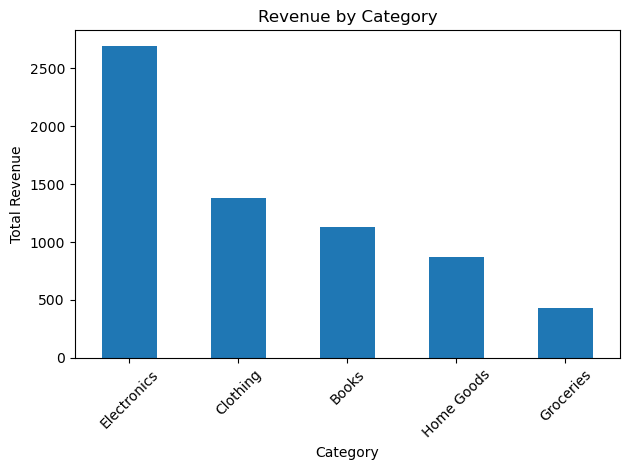

In [178]:
category_revenue.plot(kind="bar")
plt.title("Revenue by Category")
plt.ylabel("Total Revenue")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()

##### 3) Finding top 5 products>>>

###### Top 5 products by quantity sold>>>

In [180]:
print("Top 5 products by quantities sold include:")
highest_selling_products=df.groupby('product')['quantity'].sum().sort_values(ascending=False).round(0).head(5)
print(top_5products)

Top 5 products by quantities sold include:
product
Self-Help          22.0
Children's Book    17.0
Jacket             16.0
Plate Set          15.0
Hat                14.0
Name: quantity, dtype: float64


##### Top 5 products by total revenue>>>

In [181]:
print("Top 5 products by revenues include:")
highest_revenue_products=df.groupby('product')['total'].sum().sort_values(ascending=False).head(5)
print(highest_revenue_products)

Top 5 products by revenues include:
product
Power Bank    844.03
USB Cable     595.95
Smartphone    504.54
Headphones    450.34
Jacket        417.05
Name: total, dtype: float64


##### Products that sell in high quantities but do not generate as much revenues and vice-versa>>

In [182]:
df.groupby('product')[['quantity','total']].sum().round(0).sort_values(by=['quantity'],
                                                                       ascending=[False])

,quantity,total
product,,
Self-Help,22.0,338.0
Children's Book,17.0,341.0
Jacket,16.0,417.0
Plate Set,15.0,327.0
Hat,13.0,337.0
Coffee,12.0,115.0
Power Bank,12.0,844.0
Fiction Novel,11.0,248.0
T-Shirt,11.0,303.0


Coffee and milk are traffic-driving products according to the data above suggesting that these products have high quantity sales but do not generate as much revenue.
However "webcam, USB cable, and power bank" can be regarded as profit-generating products indicating low quantity sales with high profit revenue.

##### 4) Look at when people shop>>>

##### Which days of the week have the highest sales>>>

In [184]:
df['date']=pd.to_datetime(df['date'])
df['day']=df['date'].dt.day_name()

In [185]:
df['day']

0        Friday
1        Friday
2        Friday
3        Friday
4        Friday
        ...    
95      Tuesday
96      Tuesday
97          NaN
98      Tuesday
99    Wednesday
Name: day, Length: 100, dtype: object

In [187]:
sales_by_day=df.groupby('day')['total'].sum().round(2)

In [188]:
print(sales_by_day)
most_sales_day=sales_by_day.idxmax()
most_sales=sales_by_day.max()
print(f"Days with the most sales are '{most_sales_day}'s' with total sales of '${most_sales}'")

day
Friday        918.17
Monday       1026.92
Saturday     2165.46
Sunday       1709.23
Tuesday       682.65
Wednesday      62.48
Name: total, dtype: float64
Days with the most sales are 'Saturday's' with total sales of '$2165.46'


##### Bar chart showing sales by days of the week>>>

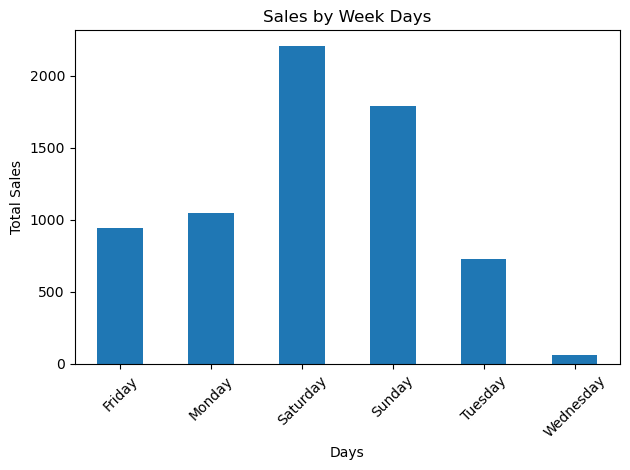

In [136]:
sales_by_day.plot(kind='bar')
plt.title("Sales by Week Days")
plt.xlabel("Days")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

##### 5) Basic Statisics>>>

In [146]:
df.describe()

,transaction_id,date,price,quantity,total
count,100.000000,100,100.000000,100.000000,100.000000
mean,10050.500000,2025-08-02 22:48:00,27.669255,2.516484,67.680171
min,10001.000000,2025-08-01 00:00:00,2.330000,1.000000,2.330000
25%,10025.750000,2025-08-02 00:00:00,13.612500,2.000000,22.760000
50%,10050.500000,2025-08-03 00:00:00,23.090000,2.516484,47.970000
75%,10075.250000,2025-08-04 00:00:00,33.095000,3.250000,89.500000
max,10100.000000,2025-08-06 00:00:00,96.890000,4.000000,383.640000
std,29.011492,NaN,21.360839,1.104286,66.398013


##### Average transaction value>>>

In [189]:
avg_transaction_value=df['total'].mean()
print(f'Average transaction Value= ${avg_transaction_value:.2f}')

Average transaction Value= $67.65


##### Average Quantity per Transaction

In [192]:
avg_quantity=df['quantity'].mean()
print(f'Average Quantity= {avg_quantity:.0f}')

Average Quantity= 2


##### Price range per category>>>

In [193]:
price_range=df.groupby('category')['price'].agg(["min","max"])
print(price_range.round(2))

               min    max
category                 
Books        10.01  29.48
Clothing     10.92  44.52
Electronics  35.68  96.89
Groceries     2.33  14.55
Home Goods    5.49  38.95


##### Key insights for the store manager about what the data tells us>>>

__ The top revenue generating category is the "Electronics" indicating that it returns the most profits. The store should prioritize stocking
and promoting products in this category.

__ The data shows a mix of products with high sales quantity but relatively low revenue sugggesting the presence of under-priced items which increase 
customer traffic while returning low profit margins and products with low sales and relatively high revenue indicating the presence of 
profit-generating items.

__ Customers spend an average of $67.65 and purchase an average of 2 products per transaction. Introducing multi-buy offers (buy 2, get 1) will 
potentially increase sales.

__ Peak sales occur on Saturdays. The store should increase staffing on said day and run promotions on slower days.

__ Missing values present in key columns; date, category and product were handled using simple techniques for accurate analysis. 